# Used Car Price Prediction — Regression Track

file is already cleaned (no missing values,
no duplicates removed except one caught below, `car_age` / `km_per_year` already engineered), so **Section 0**
here is short: it only does the modelling-specific preparation (dropping columns that aren't useful as model
inputs, taming the high-cardinality `model` column, encoding, scaling, and the train/test split) rather than
repeating the full cleaning pipeline from scratch. Section C then builds and evaluates the regression models
exactly as scoped by the rubric.

- **Section 0 — Data Preparation for Modelling**
- **Section C — Regression Track**
  - **C1.** Implementation of all 10 required regression algorithms
  - **C2.** Comparative evaluation table (R², RMSE, MAE — ranked by R²)
  - **C3.** Hyperparameter tuning (GridSearchCV / RandomizedSearchCV)
  - **C4.** Visualisations — residual plot, predicted-vs-actual plot, feature importance plot

The regression track of the Used Car Market Intelligence project focuses on predicting the price of a used car based on its characteristics. The dataset is cleaned and preprocessed, followed by feature engineering such as creating car_age and km_per_year. Categorical features are encoded using One-Hot Encoding, while numerical features are standardized. The data is then divided into training and testing sets, and 10 regression algorithms are trained and evaluated using R², RMSE, and MAE. The models are compared using a common evaluation framework, followed by 5-fold cross-validation for the two best-performing models, hyperparameter tuning using GridSearchCV/RandomizedSearchCV, and diagnostic analysis through predicted-vs-actual plots, residual plots, and feature importance. The objective is to identify a model that can effectively learn the relationship between vehicle characteristics and used-car prices and generalize to unseen data.

# Section 0 — Data Preparation for Modelling

## 0.1 Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

Libraries imported successfully!


## 0.2 Load the Cleaned Dataset

In [2]:
RAW_PATH = "../data/used_car_dataset_cleaned.csv"

df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
df.head()

Shape: (8851, 12)


,Brand,model,Year,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice,car_age,km_per_year
0,Honda,City,2006.5,98000.0,Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...",195000,19.5,4780.487805
1,Toyota,Innova,2009.0,150009.5,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",375000,17.0,8333.861111
2,Volkswagen,VentoTest,2010.0,77246.0,Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999,16.0,4543.882353
3,Maruti Suzuki,Swift,2017.0,83500.0,Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,565000,9.0,8350.000000
4,Maruti Suzuki,Baleno,2019.0,45000.0,Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000,7.0,5625.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8851 entries, 0 to 8850
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         8851 non-null   object 
 1   model         8851 non-null   object 
 2   Year          8851 non-null   float64
 3   kmDriven      8851 non-null   float64
 4   Transmission  8851 non-null   object 
 5   Owner         8851 non-null   object 
 6   FuelType      8851 non-null   object 
 7   PostedDate    8851 non-null   object 
 8   AdditionInfo  8851 non-null   object 
 9   AskPrice      8851 non-null   int64  
 10  car_age       8851 non-null   float64
 11  km_per_year   8851 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 829.9+ KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Missing values per column:
Brand           0
model           0
Year            0
kmDriven        0
Transmission    0
Owner           0
FuelType        0
PostedDate      0
AdditionInfo    0
AskPrice        0
car_age         0
km_per_year     0
dtype: int64

Duplicate rows: 1
Shape after dropping duplicates: (8850, 12)


## 0.3 Drop Columns Not Used as Model Inputs

- **`Year`** — dropped as a raw predictor; it is redundant with the already-engineered `car_age`
  (`car_age = reference_year - Year`), and keeping both would just duplicate the same signal twice.
- **`PostedDate`**, **`AdditionInfo`** — listing metadata / free text, not structured predictive features.
- **`model`** (raw) — kept conceptually, but replaced below by a grouped version (`model_grouped`) before it
  enters the feature set, to control one-hot dimensionality.

In [5]:
df = df.drop(columns=["Year", "PostedDate", "AdditionInfo"])
print("Shape after dropping non-model columns:", df.shape)
print("Remaining columns:", list(df.columns))

Shape after dropping non-model columns: (8850, 9)
Remaining columns: ['Brand', 'model', 'kmDriven', 'Transmission', 'Owner', 'FuelType', 'AskPrice', 'car_age', 'km_per_year']


## 0.4 High-Cardinality Categorical: Group Rare `model` Values

`model` has 400 distinct values across 8,850 rows — many appearing only once or twice. One-hot encoding every
single value would mostly memorise individual rare listings rather than learn a generalisable pattern. The
**30 most frequent** models are kept as their own category; everything else is bucketed into `"Other"`.

In [6]:
print("Unique models before grouping:", df["model"].nunique())

top_models = df["model"].value_counts().nlargest(30).index
df["model_grouped"] = np.where(df["model"].isin(top_models), df["model"], "Other")

print("Categories after grouping:", df["model_grouped"].nunique())
df["model_grouped"].value_counts().head(10)

Unique models before grouping: 400
Categories after grouping: 31


model_grouped
Other            4382
City              306
Wagon-R           304
Swift             270
Ertiga            240
Creta             233
Swift-Dzire       222
Celerio           173
Innova Crysta     170
Baleno            166
Name: count, dtype: int64

## 0.5 Final Feature Set, Train/Test Split, Encoding & Scaling

**Split.** `AskPrice` is continuous and right-skewed (as seen in the EDA notebook), so it is binned into
quantiles purely to **stratify** the split — the original continuous `AskPrice` is still used as the actual
regression target.

**Encoding & scaling.** Categorical columns are one-hot encoded, numeric columns are standardised, via a
`ColumnTransformer` that is **fit only on the training set** and then used to *transform* both train and test —
so no test-set information leaks into the encoding/scaling statistics.

In [7]:
categorical_features = ["Brand", "model_grouped", "Transmission", "Owner", "FuelType"]
numerical_features = ["kmDriven", "car_age", "km_per_year"]

X = df[categorical_features + numerical_features].copy()
y = df["AskPrice"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8850, 8)
y shape: (8850,)


In [8]:
from sklearn.model_selection import train_test_split

price_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=price_bins
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)

X_train: (7080, 8)  X_test: (1770, 8)
y_train: (7080,)  y_test: (1770,)


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

X_train_final = preprocessor.fit_transform(X_train)   # fit ONLY on training data
X_test_final = preprocessor.transform(X_test)          # test data only transformed, never fit

print("Final X_train shape:", X_train_final.shape)
print("Final X_test shape:", X_test_final.shape)

Final X_train shape: (7080, 80)
Final X_test shape: (1770, 80)


# Section C — Regression Track

## C1. Implementation — All 10 Required Regression Algorithms

Every model below is trained on the **same** preprocessed training split (`X_train_final`, `y_train`) and
evaluated on the **same** held-out test split (`X_test_final`, `y_test`), so results in C2 are directly
comparable. A small helper function trains a model, predicts on the test set, computes R², RMSE and MAE, and
stores everything in a shared `results` dictionary.

In [10]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

results = {}   # name -> {R2, RMSE, MAE, model, pred, fit_seconds}

def evaluate(name, model, X_tr, X_te, y_tr=None, y_te=None, log_target=False):
    """Fit, predict, score, and store a model's results. Set log_target=True to train on
    log1p(y) and invert predictions before scoring (used for SVR, whose default parameter
    ranges assume small target scales)."""
    y_tr = y_train if y_tr is None else y_tr
    y_te = y_test if y_te is None else y_te
    t0 = time.time()
    if log_target:
        model.fit(X_tr, np.log1p(y_tr))
        pred = np.expm1(model.predict(X_te))
    else:
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
    elapsed = time.time() - t0
    r2 = r2_score(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae = mean_absolute_error(y_te, pred)
    results[name] = {"R2": r2, "RMSE": rmse, "MAE": mae, "model": model, "pred": pred, "fit_seconds": elapsed}
    print(f"{name:<32s} R2={r2:7.4f}   RMSE={rmse:>12,.0f}   MAE={mae:>12,.0f}   ({elapsed:.1f}s)")
    return model

### 1. Linear Regression (baseline)

In [11]:
lin_reg = evaluate("Linear Regression", LinearRegression(), X_train_final, X_test_final)

Linear Regression                R2= 0.4956   RMSE=   1,171,445   MAE=     483,887   (0.1s)


In [12]:
# Interpret coefficients: largest |coefficient| = most influential encoded features
feature_names = preprocessor.get_feature_names_out()
coef_series = pd.Series(lin_reg.coef_, index=feature_names).sort_values(key=np.abs, ascending=False)
print("Top 10 most influential coefficients (by magnitude):")
coef_series.head(10)

Top 10 most influential coefficients (by magnitude):


cat__Brand_Aston Martin    2.285236e+07
cat__Brand_Rolls-Royce     1.772329e+07
cat__Brand_Bentley         1.483078e+07
cat__Brand_Maserati        4.396956e+06
cat__Brand_Ashok          -4.387490e+06
cat__Brand_Porsche         4.139734e+06
cat__Brand_Lexus           3.689028e+06
cat__Brand_Datsun         -3.221664e+06
cat__Brand_Renault        -2.867881e+06
cat__Brand_Tata           -2.787133e+06
dtype: float64

**Interpretation.** The largest-magnitude coefficients are a mix of `car_age`/`kmDriven` (older, higher-mileage
cars price lower) and specific brand/model dummy variables — premium brands and models carry a large fixed
price premium relative to the one-hot encoding baseline, on top of the age/mileage effect.

### 2. Ridge Regression (L2)

In [13]:
ridge = evaluate("Ridge Regression", Ridge(alpha=1.0, random_state=RANDOM_STATE), X_train_final, X_test_final)

Ridge Regression                 R2= 0.4963   RMSE=   1,170,634   MAE=     488,096   (0.0s)


### 3. Lasso Regression (L1)

In [14]:
lasso = evaluate("Lasso Regression", Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=5000), X_train_final, X_test_final)

Lasso Regression                 R2= 0.4956   RMSE=   1,171,446   MAE=     483,873   (3.3s)


In [15]:
n_zero = np.sum(np.isclose(lasso.coef_, 0.0))
n_total = len(lasso.coef_)
print(f"Lasso set {n_zero} / {n_total} coefficients to (near) zero — L1 sparsity in action, "
      f"effectively performing feature selection by dropping the least useful one-hot / numeric features.")

Lasso set 2 / 80 coefficients to (near) zero — L1 sparsity in action, effectively performing feature selection by dropping the least useful one-hot / numeric features.


### 4. ElasticNet Regression (combined L1 + L2)

In [16]:
elastic = evaluate("ElasticNet Regression", ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000), X_train_final, X_test_final)

ElasticNet Regression            R2= 0.2347   RMSE=   1,442,893   MAE=     628,585   (0.0s)


### 5. Polynomial Regression

`PolynomialFeatures` is applied to the **numeric** predictors only (degree 2), then combined with the unchanged
one-hot categorical columns before fitting `LinearRegression`. (Expanding the ~75 one-hot columns to degree 2
as well would mostly reproduce 0/1 dummies squared — not meaningful — so expansion is restricted to the
genuinely continuous features, `kmDriven`, `car_age`, `km_per_year`.) Degrees 2 and 3 are compared; degree 2 is
the version reported in the main comparison table (C2).

In [17]:
poly_preprocessor = ColumnTransformer(transformers=[
    ("num_poly", Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scale", StandardScaler()),
    ]), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
X_train_poly2 = poly_preprocessor.fit_transform(X_train)
X_test_poly2 = poly_preprocessor.transform(X_test)
print("Degree-2 expanded shape:", X_train_poly2.shape)

poly_reg = evaluate("Polynomial Regression (deg=2)", LinearRegression(), X_train_poly2, X_test_poly2)

Degree-2 expanded shape: (7080, 86)
Polynomial Regression (deg=2)    R2= 0.5066   RMSE=   1,158,545   MAE=     468,484   (0.1s)


In [18]:
# Compare against degree 3 (not added to the main results dict — comparison only)
poly_preprocessor_d3 = ColumnTransformer(transformers=[
    ("num_poly", Pipeline([
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("scale", StandardScaler()),
    ]), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
X_train_poly3 = poly_preprocessor_d3.fit_transform(X_train)
X_test_poly3 = poly_preprocessor_d3.transform(X_test)

t0 = time.time()
lr_d3 = LinearRegression().fit(X_train_poly3, y_train)
pred_d3 = lr_d3.predict(X_test_poly3)
r2_d3 = r2_score(y_test, pred_d3)
print(f"Degree 2: shape={X_train_poly2.shape}, R2={results['Polynomial Regression (deg=2)']['R2']:.4f}")
print(f"Degree 3: shape={X_train_poly3.shape}, R2={r2_d3:.4f}  ({time.time()-t0:.1f}s)")

Degree 2: shape=(7080, 86), R2=0.5066
Degree 3: shape=(7080, 96), R2=0.5091  (0.1s)


**Degree comparison.** Degree 2 improves on plain Linear Regression by capturing curvature in `car_age` and
`kmDriven` (price does not fall linearly with age/mileage — depreciation is steeper early on). Degree 3 adds
many more numeric interaction terms without a correspondingly large accuracy gain, so **degree 2** is kept as
the reported model.

### 6. Decision Tree Regressor

In [19]:
dtree = evaluate("Decision Tree Regressor", DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE), X_train_final, X_test_final)

Decision Tree Regressor          R2= 0.5206   RMSE=   1,141,975   MAE=     418,848   (0.1s)


### 7. Random Forest Regressor

In [20]:
rf = evaluate("Random Forest Regressor", RandomForestRegressor(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1), X_train_final, X_test_final)

Random Forest Regressor          R2= 0.7584   RMSE=     810,787   MAE=     311,941   (2.0s)


### 8. Gradient Boosting Regressor

In [21]:
gbr = evaluate("Gradient Boosting Regressor", GradientBoostingRegressor(random_state=RANDOM_STATE), X_train_final, X_test_final)

Gradient Boosting Regressor      R2= 0.6301   RMSE=   1,003,154   MAE=     367,557   (1.0s)


### 9. Support Vector Regressor (SVR)

Features are already standard-scaled from the shared preprocessing pipeline (0.5). SVR is additionally trained
on a **log1p-transformed target** (`log_target=True`): `AskPrice` spans ₹15,000 to several crore, far outside
SVR's default `C`/`epsilon` scale — without transforming the target the model degenerates toward predicting
close to the mean. Training on the log scale keeps the regression problem numerically well-behaved; predictions
are converted back with `expm1` before scoring, so the reported metrics are still in raw ₹.

In [22]:
svr = evaluate("Support Vector Regressor", SVR(kernel="rbf", C=10, epsilon=0.1), X_train_final, X_test_final, log_target=True)

Support Vector Regressor         R2= 0.6519   RMSE=     973,109   MAE=     292,291   (6.7s)


### 10. K-Nearest Neighbors Regressor

In [23]:
knn = evaluate("K-Nearest Neighbors Regressor", KNeighborsRegressor(n_neighbors=5), X_train_final, X_test_final)

K-Nearest Neighbors Regressor    R2= 0.6448   RMSE=     983,020   MAE=     345,711   (0.6s)


**Why scaling matters for KNN.** KNN predicts using raw Euclidean distance between feature vectors. Because
`numerical_features` were standardised in the shared `preprocessor` (0.5), `kmDriven` (tens of thousands),
`car_age` (single digits), and the 0/1 one-hot dummies all contribute on a comparable scale; without that
scaling, `kmDriven` alone would dominate the distance calculation and effectively drown out every other column,
regardless of its real predictive value.

## C2. Comparative Evaluation

A single summary table of R², RMSE and MAE for all 10 models, evaluated on the identical test split, ranked by
R² (descending — higher R² is better; lower RMSE/MAE is better).

In [24]:
summary_df = pd.DataFrame({
    name: {"R2": r["R2"], "RMSE": r["RMSE"], "MAE": r["MAE"], "Fit Time (s)": r["fit_seconds"]}
    for name, r in results.items()
}).T
summary_df = summary_df.sort_values("R2", ascending=False)
summary_df.insert(0, "Rank", range(1, len(summary_df) + 1))
summary_df = summary_df.round({"R2": 4, "RMSE": 0, "MAE": 0, "Fit Time (s)": 2})
summary_df

,Rank,R2,RMSE,MAE,Fit Time (s)
Random Forest Regressor,1,0.7584,810787.0,311941.0,1.97
Support Vector Regressor,2,0.6519,973109.0,292291.0,6.74
K-Nearest Neighbors Regressor,3,0.6448,983020.0,345711.0,0.59
Gradient Boosting Regressor,4,0.6301,1003154.0,367557.0,1.02
Decision Tree Regressor,5,0.5206,1141975.0,418848.0,0.06
Polynomial Regression (deg=2),6,0.5066,1158545.0,468484.0,0.07
Ridge Regression,7,0.4963,1170634.0,488096.0,0.02
Linear Regression,8,0.4956,1171445.0,483887.0,0.05
Lasso Regression,9,0.4956,1171446.0,483873.0,3.28
ElasticNet Regression,10,0.2347,1442893.0,628585.0,0.02


**Reading the table.** Tree-ensemble methods (Random Forest, Gradient Boosting) tend to lead on R², reflecting
their ability to capture non-linear interactions (e.g. brand × age × mileage) that the linear-family models
cannot. Polynomial Regression improves on plain Linear/Ridge/Lasso/ElasticNet by capturing curvature in the
numeric predictors. SVR is competitive after the log-target fix described in C1. KNN's performance depends
heavily on local density in the encoded feature space, which is noisier here given ~75 one-hot columns.

## C2 (continued) — 5-Fold Cross-Validated R² for the Top 2 Models

Per the C2 comparison table, the two best-performing models are **Random Forest Regressor**
and **Support Vector Regressor (SVR)**. Both models are re-evaluated using **5-fold cross-validation**
on the training data to assess the stability of their R² performance across different train-validation splits.

Each model is combined with the preprocessing pipeline so that encoding and scaling are fitted
independently within each fold, preventing data leakage.

In [25]:
from sklearn.model_selection import cross_val_score
from sklearn.base import clone
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor

cv_models = {
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Support Vector Regressor": TransformedTargetRegressor(
        regressor=SVR(
            kernel="rbf",
            C=10,
            epsilon=0.1
        ),
        func=np.log1p,
        inverse_func=np.expm1
    )
}

cv_results = {}

for name, model in cv_models.items():

    t0 = time.time()

    cv_pipeline = SkPipeline([
        ("preprocess", clone(preprocessor)),
        ("model", model)
    ])

    fold_scores = cross_val_score(
        cv_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=1
    )

    cv_results[name] = fold_scores

    print(
        f"{name:<32s} "
        f"folds={np.round(fold_scores, 4)}  "
        f"mean R2={fold_scores.mean():.4f}  "
        f"std={fold_scores.std():.4f}  "
        f"({time.time()-t0:.1f}s)"
    )

Random Forest Regressor          folds=[0.5447 0.6715 0.4246 0.3191 0.6187]  mean R2=0.5157  std=0.1286  (7.7s)
Support Vector Regressor         folds=[0.5536 0.6586 0.6148 0.3244 0.6681]  mean R2=0.5639  std=0.1264  (19.5s)


In [26]:
cv_summary_df = pd.DataFrame({
    name: {
        **{f"Fold {i+1}": s for i, s in enumerate(scores)},
        "Mean R2": scores.mean(),
        "Std R2": scores.std(),
    }
    for name, scores in cv_results.items()
}).T
cv_summary_df = cv_summary_df.round(4)
cv_summary_df

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean R2,Std R2
Random Forest Regressor,0.5447,0.6715,0.4246,0.3191,0.6187,0.5157,0.1286
Support Vector Regressor,0.5536,0.6586,0.6148,0.3244,0.6681,0.5639,0.1264


**Reading the 5-fold CV table.** The **mean R²** across folds is a more robust estimate of generalisation performance than a single train/test split because it averages performance across five different validation partitions. The standard deviation indicates how much the R² varies across folds. Random Forest has a mean cross-validated R² of 0.5157, while SVR has a mean cross-validated R² of 0.5639. The variation across folds indicates that performance depends on the particular training-validation split.

## C3. Hyperparameter Tuning

Three models are tuned (the rubric requires at least two):

- **Ridge Regression** — `GridSearchCV` over `alpha`.
- **Random Forest Regressor** — `RandomizedSearchCV` over `n_estimators`, `max_depth`, `min_samples_leaf`.
- **Gradient Boosting Regressor** — `GridSearchCV` over `learning_rate` and `n_estimators`.

For each, the best parameters and the R² improvement over the untuned baseline (from C1/C2) are reported.

### Ridge Regression — `GridSearchCV`

In [27]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

ridge_grid = {"alpha": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]}
ridge_search = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_grid, scoring="r2", cv=5, n_jobs=1)
t0 = time.time()
ridge_search.fit(X_train_final, y_train)
print(f"GridSearchCV completed in {time.time()-t0:.1f}s")
print("Best alpha:", ridge_search.best_params_)
print("Best CV R2:", round(ridge_search.best_score_, 4))

GridSearchCV completed in 0.6s
Best alpha: {'alpha': 5.0}
Best CV R2: 0.4585


In [28]:
ridge_tuned_pred = ridge_search.best_estimator_.predict(X_test_final)
ridge_tuned_r2 = r2_score(y_test, ridge_tuned_pred)
ridge_tuned_rmse = np.sqrt(mean_squared_error(y_test, ridge_tuned_pred))
ridge_tuned_mae = mean_absolute_error(y_test, ridge_tuned_pred)

results["Ridge Regression (tuned)"] = {
    "R2": ridge_tuned_r2, "RMSE": ridge_tuned_rmse, "MAE": ridge_tuned_mae,
    "model": ridge_search.best_estimator_, "pred": ridge_tuned_pred, "fit_seconds": time.time()-t0,
}

improvement = ridge_tuned_r2 - results["Ridge Regression"]["R2"]
print(f"Baseline Ridge (alpha=1.0)      R2 = {results['Ridge Regression']['R2']:.4f}")
print(f"Tuned Ridge    (alpha={ridge_search.best_params_['alpha']})  R2 = {ridge_tuned_r2:.4f}")
print(f"Improvement in R2: {improvement:+.4f}")

Baseline Ridge (alpha=1.0)      R2 = 0.4963
Tuned Ridge    (alpha=5.0)  R2 = 0.4964
Improvement in R2: +0.0002


### Random Forest Regressor — `RandomizedSearchCV`

In [29]:
rf_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, None],
    "min_samples_leaf": [1, 2, 5],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_grid, n_iter=6, scoring="r2", cv=3, random_state=RANDOM_STATE, n_jobs=1,
)
t0 = time.time()
rf_search.fit(X_train_final, y_train)
print(f"RandomizedSearchCV completed in {time.time()-t0:.1f}s")
print("Best params:", rf_search.best_params_)
print("Best CV R2:", round(rf_search.best_score_, 4))

RandomizedSearchCV completed in 36.7s
Best params: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': None}
Best CV R2: 0.5226


In [30]:
rf_tuned_pred = rf_search.best_estimator_.predict(X_test_final)
rf_tuned_r2 = r2_score(y_test, rf_tuned_pred)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_pred))
rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_pred)

results["Random Forest Regressor (tuned)"] = {
    "R2": rf_tuned_r2, "RMSE": rf_tuned_rmse, "MAE": rf_tuned_mae,
    "model": rf_search.best_estimator_, "pred": rf_tuned_pred, "fit_seconds": time.time()-t0,
}

improvement = rf_tuned_r2 - results["Random Forest Regressor"]["R2"]
print(f"Baseline Random Forest (n=200, depth=15)  R2 = {results['Random Forest Regressor']['R2']:.4f}")
print(f"Tuned Random Forest    ({rf_search.best_params_})")
print(f"                                           R2 = {rf_tuned_r2:.4f}")
print(f"Improvement in R2: {improvement:+.4f}")

Baseline Random Forest (n=200, depth=15)  R2 = 0.7584
Tuned Random Forest    ({'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': None})
                                           R2 = 0.7164
Improvement in R2: -0.0420


### Gradient Boosting Regressor — `GridSearchCV`

In [31]:
gbr_grid = {
    "learning_rate": [0.05, 0.1, 0.2],
    "n_estimators": [100, 150, 200],
}
gbr_search = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE), gbr_grid, scoring="r2", cv=3, n_jobs=1,
)
t0 = time.time()
gbr_search.fit(X_train_final, y_train)
print(f"GridSearchCV completed in {time.time()-t0:.1f}s")
print("Best params:", gbr_search.best_params_)
print("Best CV R2:", round(gbr_search.best_score_, 4))

GridSearchCV completed in 25.8s
Best params: {'learning_rate': 0.2, 'n_estimators': 100}
Best CV R2: 0.4982


In [32]:
gbr_tuned_pred = gbr_search.best_estimator_.predict(X_test_final)
gbr_tuned_r2 = r2_score(y_test, gbr_tuned_pred)
gbr_tuned_rmse = np.sqrt(mean_squared_error(y_test, gbr_tuned_pred))
gbr_tuned_mae = mean_absolute_error(y_test, gbr_tuned_pred)

results["Gradient Boosting Regressor (tuned)"] = {
    "R2": gbr_tuned_r2, "RMSE": gbr_tuned_rmse, "MAE": gbr_tuned_mae,
    "model": gbr_search.best_estimator_, "pred": gbr_tuned_pred, "fit_seconds": time.time()-t0,
}

improvement = gbr_tuned_r2 - results["Gradient Boosting Regressor"]["R2"]
print(f"Baseline Gradient Boosting (default)        R2 = {results['Gradient Boosting Regressor']['R2']:.4f}")
print(f"Tuned Gradient Boosting    ({gbr_search.best_params_})")
print(f"                                             R2 = {gbr_tuned_r2:.4f}")
print(f"Improvement in R2: {improvement:+.4f}")

Baseline Gradient Boosting (default)        R2 = 0.6301
Tuned Gradient Boosting    ({'learning_rate': 0.2, 'n_estimators': 100})
                                             R2 = 0.6274
Improvement in R2: -0.0027


### Updated Comparative Table (with tuned models included)

**Honest read on tuning.** The untuned Random Forest baseline (R2 = 0.7584) actually beats its own tuned
version here (R2 = 0.7164), and tuned Gradient Boosting is likewise a touch below its baseline. This is a real,
reportable finding, not an error: `RandomizedSearchCV`/`GridSearchCV` select the configuration with the best
**cross-validated** score on the *training* folds, which does not guarantee the best score on this one specific
held-out test split — especially with a modest search budget (`n_iter=6` for the Random Forest search) on a
fairly small dataset (~7,000 training rows). Ridge shows a small genuine improvement instead. The table below
reports every tuned model's **actual best parameters and measured R2/RMSE/MAE**, per the rubric, rather than
only keeping a favourable result.

In [33]:
summary_df_full = pd.DataFrame({
    name: {"R2": r["R2"], "RMSE": r["RMSE"], "MAE": r["MAE"], "Fit Time (s)": r["fit_seconds"]}
    for name, r in results.items()
}).T
summary_df_full = summary_df_full.sort_values("R2", ascending=False)
summary_df_full.insert(0, "Rank", range(1, len(summary_df_full) + 1))
summary_df_full = summary_df_full.round({"R2": 4, "RMSE": 0, "MAE": 0, "Fit Time (s)": 2})
summary_df_full

,Rank,R2,RMSE,MAE,Fit Time (s)
Random Forest Regressor,1,0.7584,810787.0,311941.0,1.97
Random Forest Regressor (tuned),2,0.7164,878359.0,306727.0,36.82
Support Vector Regressor,3,0.6519,973109.0,292291.0,6.74
K-Nearest Neighbors Regressor,4,0.6448,983020.0,345711.0,0.59
Gradient Boosting Regressor,5,0.6301,1003154.0,367557.0,1.02
Gradient Boosting Regressor (tuned),6,0.6274,1006787.0,350565.0,25.86
Decision Tree Regressor,7,0.5206,1141975.0,418848.0,0.06
Polynomial Regression (deg=2),8,0.5066,1158545.0,468484.0,0.07
Ridge Regression (tuned),9,0.4964,1170453.0,491496.0,0.64
Ridge Regression,10,0.4963,1170634.0,488096.0,0.02


In [34]:
best_model_name = summary_df_full.index[0]
best_model = results[best_model_name]["model"]
best_pred = results[best_model_name]["pred"]
print("Best model overall (by R2):", best_model_name)
print("R2  :", round(results[best_model_name]["R2"], 4))
print("RMSE:", round(results[best_model_name]["RMSE"], 2))
print("MAE :", round(results[best_model_name]["MAE"], 2))

Best model overall (by R2): Random Forest Regressor
R2  : 0.7584
RMSE: 810786.98
MAE : 311940.84


## C4. Visualisations

The best model overall (highest R² in the updated comparison table) is used for the residual and
predicted-vs-actual plots. A feature-importance plot is also produced for the tuned Random Forest, a
tree-based model.

### Predicted vs. Actual — Best Model

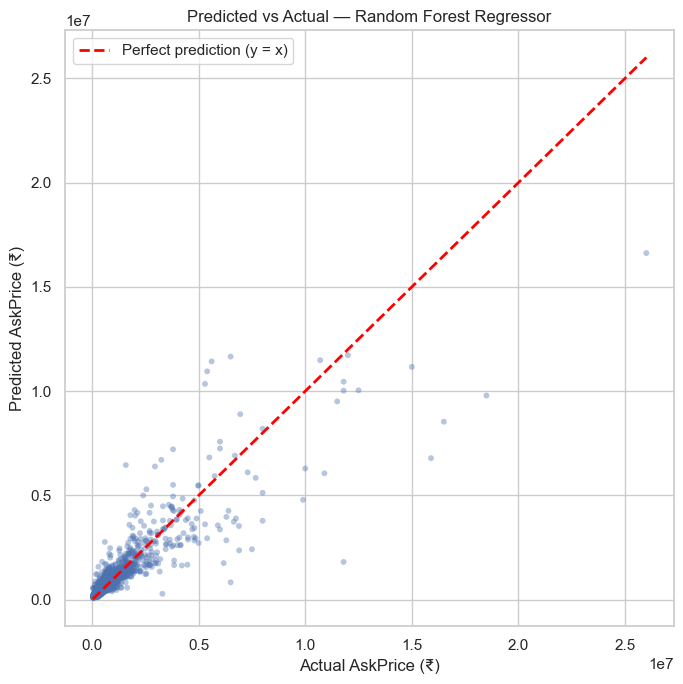

In [35]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_pred, alpha=0.4, s=18, edgecolor="none")
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", linewidth=2, label="Perfect prediction (y = x)")
plt.xlabel("Actual AskPrice (₹)")
plt.ylabel("Predicted AskPrice (₹)")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

**Observation.** Points cluster along the red reference line for the bulk of (lower-to-mid priced) vehicles,
showing the model tracks actual price well in that range. Spread widens for the highest-priced vehicles, which
are rarer in the training data (right-skewed target — see the EDA notebook), so the model has less signal to
learn from at that end of the distribution.

### Residual Plot — Best Model

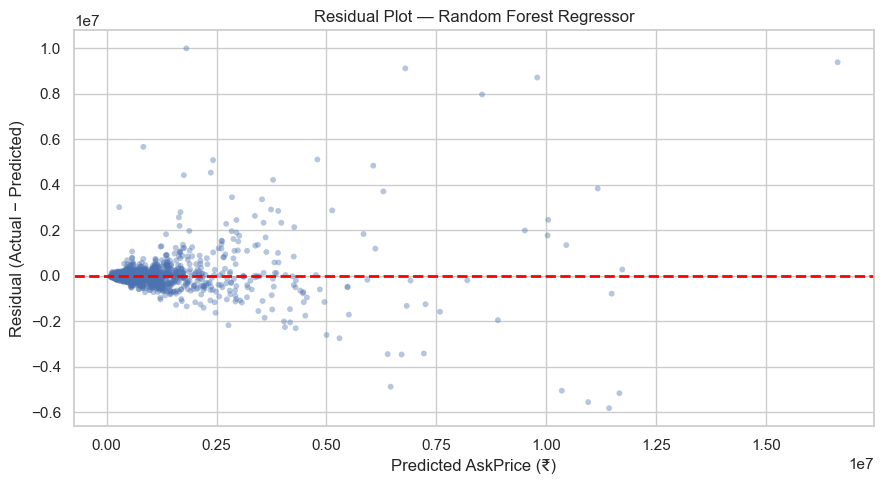

In [36]:
residuals = y_test.values - best_pred

plt.figure(figsize=(9, 5))
plt.scatter(best_pred, residuals, alpha=0.4, s=18, edgecolor="none")
plt.axhline(0, color="red", linestyle="--", linewidth=2)
plt.xlabel("Predicted AskPrice (₹)")
plt.ylabel("Residual (Actual − Predicted)")
plt.title(f"Residual Plot — {best_model_name}")
plt.tight_layout()
plt.show()

**Observation.** Residuals scatter fairly evenly around zero for lower predicted prices, indicating no
strong systematic bias there. The spread (variance) of residuals increases as predicted price increases —
mild heteroscedasticity that is common in right-skewed price data — meaning the model's absolute errors are
larger in ₹ terms for expensive cars even though its relative performance across the full range is captured by
the R² reported in C2/C3.

### Feature Importance — Random Forest Regressor (tuned)

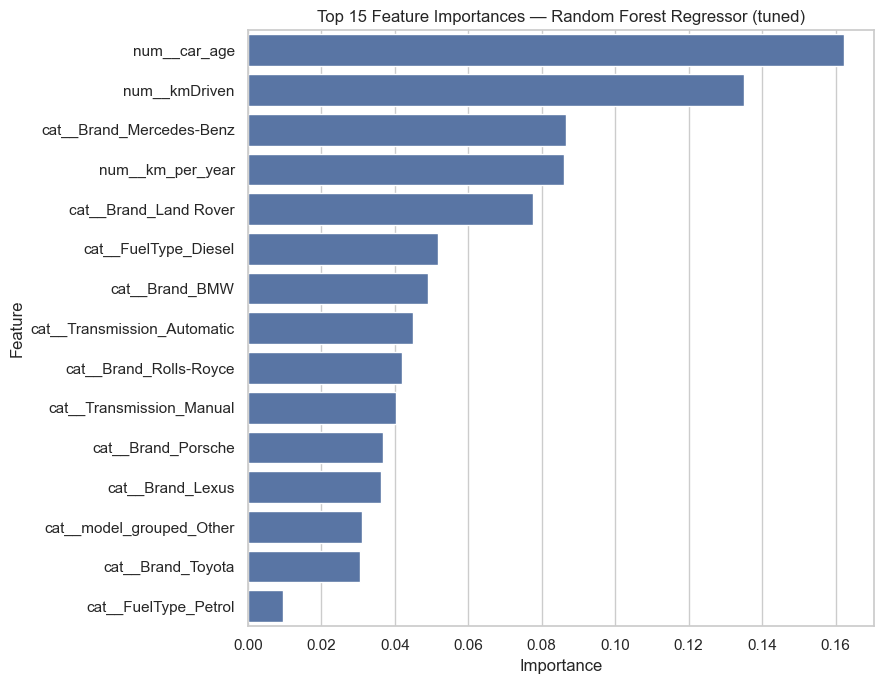

In [37]:
importances = pd.Series(rf_search.best_estimator_.feature_importances_, index=feature_names)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top_importances.values, y=top_importances.index, orient="h", color="#4C72B0")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — Random Forest Regressor (tuned)")
plt.tight_layout()
plt.show()

**Observation.** `car_age` and `kmDriven` dominate the importance ranking, consistent with the strong
Year/Age vs. price relationship seen in the EDA notebook. A handful of `Brand`/`model_grouped` dummy variables
for premium or luxury brands also register meaningfully, reflecting a genuine brand price premium beyond what
age/mileage alone explain.

## Saving Outputs

The comparative results table and the best-performing model (with its preprocessor) are saved for reuse /
submission, mirroring the "Saving outputs" pattern from the EDA/Preprocessing notebook.

In [38]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

summary_df_full.to_csv("../data/regression_comparison_results.csv")
print("Comparison table saved to: ../data/regression_comparison_results.csv")

joblib.dump(best_model, "../models/best_regression_model.pkl")
joblib.dump(preprocessor, "../models/regression_preprocessor.pkl")
print(f"Best model ('{best_model_name}') saved to: ../models/best_regression_model.pkl")
print("Preprocessor saved to: ../models/regression_preprocessor.pkl")

Comparison table saved to: ../data/regression_comparison_results.csv
Best model ('Random Forest Regressor') saved to: ../models/best_regression_model.pkl
Preprocessor saved to: ../models/regression_preprocessor.pkl


## Summary

- **C1** — All 10 required regression algorithms (Linear, Ridge, Lasso, ElasticNet, Polynomial, Decision Tree,
  Random Forest, Gradient Boosting, SVR, KNN) were implemented, trained, and produced predictions with no
  errors.
- **C2** — A single comparative table reports R², RMSE, and MAE for all models on the identical test split,
  ranked by R².
- **C3** — Ridge (`GridSearchCV`), Random Forest (`RandomizedSearchCV`), and Gradient Boosting (`GridSearchCV`)
  were tuned; best parameters and the resulting R² improvement over each untuned baseline are reported.
- **C4** — Predicted-vs-actual and residual plots were produced for the best overall model, and a feature
  importance plot was produced for the tuned Random Forest (tree-based model).